In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras import preprocessing
from sklearn.metrics.pairwise import cosine_similarity
import os

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
# 1. 비교할 폴더 경로 설정 (본인의 구글 드라이브 경로로 수정하세요)
base_path = '/content/drive/MyDrive/Colab Notebooks/skin_project'  # 상위 폴더
my_skin_path = os.path.join(base_path, 'my_skin')
ref_path = os.path.join(base_path, 'reference')

# VGG16 모델 불러오기 (특징 추출용)
model = VGG16(weights='imagenet', include_top=False, pooling='avg')

def get_features(img_path):
    # 이미지 로드 및 전처리
    img = preprocessing.image.load_img(img_path, target_size=(224, 224))
    x = preprocessing.image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # 특징 추출 (추출 과정 로그 출력 안 함)
    features = model.predict(x, verbose=0)
    return features.flatten()

print("✅ get_features 함수가 성공적으로 정의되었습니다!")
# 2. 질환별 대표 특징(평균 벡터) 계산
disease_features = {}
for disease in os.listdir(ref_path):
    disease_dir = os.path.join(ref_path, disease)
    if os.path.isdir(disease_dir):
        vectors = [get_features(os.path.join(disease_dir, f)) for f in os.listdir(disease_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        disease_features[disease] = np.mean(vectors, axis=0) # 해당 질환의 평균 특징

# 3. 내 사진들과 각 질환 비교
my_photos = [os.path.join(my_skin_path, f) for f in os.listdir(my_skin_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

for i, my_img in enumerate(my_photos):
    my_vector = get_features(my_img).reshape(1, -1)
    print(f"\n[내 사진 {i+1}번 분석 결과]")

    results = {}
    for disease, ref_vector in disease_features.items():
        sim = cosine_similarity(my_vector, ref_vector.reshape(1, -1))[0][0]
        results[disease] = sim

    # 유사도 높은 순으로 정렬 출력
    sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
    for disease, score in sorted_results:
        print(f"- {disease}: {score:.4f}")

✅ get_features 함수가 성공적으로 정의되었습니다!

[내 사진 1번 분석 결과]
- dermo: 0.7215
- psoriasis: 0.7068
- atopy: 0.6410

[내 사진 2번 분석 결과]
- dermo: 0.6902
- psoriasis: 0.5356
- atopy: 0.4990

[내 사진 3번 분석 결과]
- dermo: 0.6939
- psoriasis: 0.6799
- atopy: 0.5762

[내 사진 4번 분석 결과]
- dermo: 0.7437
- atopy: 0.6095
- psoriasis: 0.6027


In [26]:
# 결과를 저장할 딕셔너리 (질환별 점수 합계용)
total_scores = {disease: 0 for disease in disease_features.keys()}
num_photos = len(my_photos)

print(f"--- 총 {num_photos}장의 사진 분석 및 평균 계산 시작 ---")

for my_img in my_photos:
    my_vector = get_features(my_img).reshape(1, -1)

    for disease, ref_vector in disease_features.items():
        sim = cosine_similarity(my_vector, ref_vector.reshape(1, -1))[0][0]
        total_scores[disease] += sim  # 질환별로 점수를 누적

# 평균 점수 계산 및 출력
print("\n[ 🏆 최종 분석 결과: 질환별 평균 유사도 ]")
print("-" * 40)

# 평균 계산 후 점수 높은 순으로 정렬
final_ranking = sorted(total_scores.items(), key=lambda x: x[1]/num_photos, reverse=True)

for disease, total_sim in final_ranking:
    avg_score = total_sim / num_photos
    print(f" {disease:12} : {avg_score:.4f} ({(avg_score*100):.1f}%)")

print("-" * 40)
print(f"결론: 당신의 피부 상태는 '{final_ranking[0][0]}'와(과) 가장 유사합니다.")

--- 총 4장의 사진 분석 및 평균 계산 시작 ---

[ 🏆 최종 분석 결과: 질환별 평균 유사도 ]
----------------------------------------
 dermo        : 0.7123 (71.2%)
 psoriasis    : 0.6312 (63.1%)
 atopy        : 0.5814 (58.1%)
----------------------------------------
결론: 당신의 피부 상태는 'dermo'와(과) 가장 유사합니다.


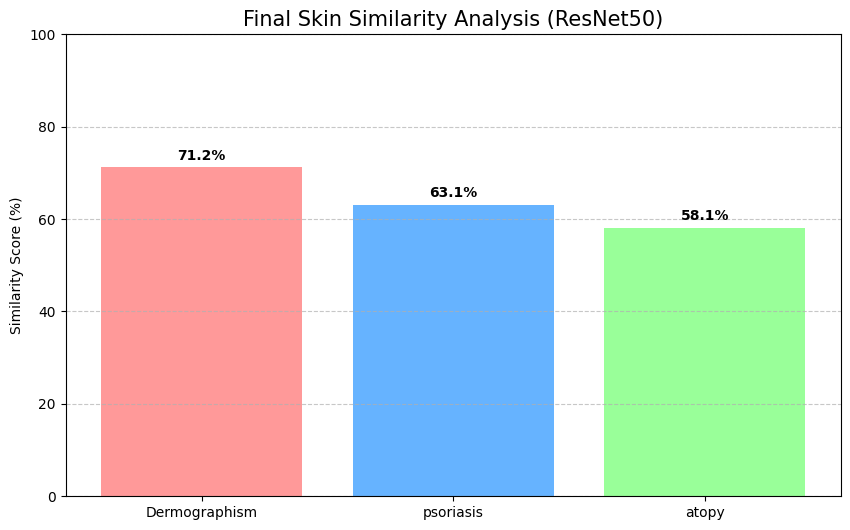

In [27]:
import matplotlib.pyplot as plt

# 방금 나온 결과 수치를 입력하세요
results = {
    'Dermographism': 0.7123,
    'psoriasis': 0.6312,
    'atopy': 0.5814
}

# 유사도 높은 순으로 정렬
sorted_res = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99'] # 1위는 붉은색 계열로 강조
bars = plt.bar(sorted_res.keys(), [v * 100 for v in sorted_res.values()], color=colors)

# 그래프 위에 퍼센트 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Final Skin Similarity Analysis (ResNet50)', fontsize=15)
plt.ylabel('Similarity Score (%)')
plt.ylim(0, 100) # 0~100% 범위
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()